# A cellular automaton inside a convolutional neural network

This notebook walks through the construction of the ACRI 2024 paper
*Efficient Simulation of Non-uniform Cellular Automata with a Convolutional Neural Network*
(Rollier, Daly, Bruno and Baetens, LNCS 14978, pp. 121–131, [doi:10.1007/978-3-031-71552-5_11](https://doi.org/10.1007/978-3-031-71552-5_11), [arXiv:2409.02722](https://arxiv.org/abs/2409.02722)),
as presented in Sec. 7.1 of the PhD thesis *The rich landscape of iterated simplicity* (Ghent University, 2026).

The point is that nothing needs to be learned: a global update of an elementary cellular automaton (ECA)
**is** a small convolutional network with 40 fixed weights, and a non-uniform CA (νCA) is the same network
in which one layer no longer shares its weights between cells. Every claim below is checked by an `assert`;
the full checks live in `verification/`.

1. The eight neighbourhood detectors (thesis Tab. 7.1)
2. The 40-parameter ECA network
3. Two networks for νCAs (Eqs. 7.1 and 7.2)
4. Bit-identity with CellPyLib and with the published figures
5. Aside: the (4, 2, 1) encoding of the paper
6. Where to go next

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.get_logger().setLevel("ERROR")  # hide TensorFlow's deprecation notices

from ca_emulators import EcaEmulator, NucaEmulator
from ca_emulators import reference, rules, weights
from ca_emulators.simulate import spacetime

rng = np.random.default_rng(2024)

## 1. The eight neighbourhood detectors

The first layer is a width-3 convolution with periodic padding and eight ReLU channels. Channel $i$ detects the
neighbourhood $(s_-, s_\circ, s_+)$ whose binary representation is $i$: its weights are $+1$ where that
neighbourhood holds a 1 and $-\omega$ where it holds a 0, and its bias is $1-h$, with $h$ the number of ones.
These are the weights the package puts into the layer:

In [2]:
kernel, bias = weights.detector_kernel(omega=5.0), weights.detector_bias()
table54 = rules.rule_table(54)
print("channel  (s-, so, s+)   weights            bias   rule 54")
for i, pattern in enumerate(rules.neighbourhood_patterns()):
    w = ", ".join(f"{v:+.0f}" for v in kernel[:, 0, i])
    print(f"{i:>7}  {tuple(int(s) for s in pattern)}      ({w})   {bias[i]:+.0f}      {table54[i]}")

channel  (s-, so, s+)   weights            bias   rule 54
      0  (0, 0, 0)      (-5, -5, -5)   +1      0
      1  (0, 0, 1)      (-5, -5, +1)   +0      1
      2  (0, 1, 0)      (-5, +1, -5)   +0      1
      3  (0, 1, 1)      (-5, +1, +1)   -1      0
      4  (1, 0, 0)      (+1, -5, -5)   +0      1
      5  (1, 0, 1)      (+1, -5, +1)   -1      1
      6  (1, 1, 0)      (+1, +1, -5)   -1      0
      7  (1, 1, 1)      (+1, +1, +1)   -2      0


For the matching neighbourhood the weighted sum is exactly 1; for any other it is at most 0 as soon as
$\omega \ge 1$. At $\omega = 1$ the pre-activation is simply one minus the Hamming distance between the input and
the channel's pattern:

In [3]:
patterns = rules.neighbourhood_patterns().astype(float)
pre_activation = patterns @ weights.detector_kernel(omega=1.0)[:, 0, :] + weights.detector_bias()
hamming = np.abs(patterns[:, None, :] - patterns[None, :, :]).sum(-1)
assert np.array_equal(pre_activation, 1 - hamming)
print(pre_activation.astype(int))   # rows: input neighbourhood, columns: channel

[[ 1  0  0 -1  0 -1 -1 -2]
 [ 0  1 -1  0 -1  0 -2 -1]
 [ 0 -1  1  0 -1 -2  0 -1]
 [-1  0  0  1 -2 -1 -1  0]
 [ 0 -1 -1 -2  1  0  0 -1]
 [-1  0 -2 -1  0  1 -1  0]
 [-1 -2  0 -1  0 -1  1  0]
 [-2 -1 -1  0 -1  0  0  1]]


After the ReLU only the diagonal survives: the eight channels form a one-hot encoding of the neighbourhood.
The cyclic de Bruijn sequence `00010111` contains each neighbourhood exactly once, so a single configuration of eight
cells shows every detector at work:

In [4]:
model = EcaEmulator(8, rule=54).model()
detectors = tf.keras.Model(model.input, model.get_layer("detectors").output)
activations = detectors(rules.DE_BRUIJN[None, :, None].astype(np.float32)).numpy()[0]
print("configuration :", rules.DE_BRUIJN)
print("active channel:", activations.argmax(axis=1))
assert np.array_equal(activations, np.eye(8)[reference.neighbourhood_index(rules.DE_BRUIJN)])

configuration : [0 0 0 1 0 1 1 1]
active channel: [4 0 1 2 5 3 7 6]


## 2. The 40-parameter ECA network

The second layer is a width-1 convolution whose eight weights are the rule table: weight $i$ is the state the rule
assigns to neighbourhood $i$. Since exactly one detector is active per cell, the output is the next configuration.
With the rule given, all weights are set analytically and frozen:

In [5]:
model = EcaEmulator(64, rule=110).model()
model.summary()
assert model.count_params() == 40 and not model.trainable_weights

Model: "eca_emulator"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 configuration (InputLayer)  [(None, 64, 1)]           0         


 periodic_padding (Periodic  (None, 66, 1)             0         


...

 output (Activation)         (None, 64, 1)             0         


Total params: 40 (160.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 40 (160.00 Byte)


_________________________________________________________________


Iterating the one-step network produces a spacetime diagram, identical to the numpy reference:

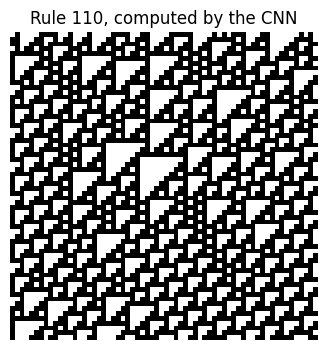

In [6]:
x0 = rng.integers(2, size=64)
diagram = EcaEmulator(64, rule=110).simulate(x0, n_updates=63)
assert np.array_equal(diagram, reference.evolve(x0, 110, 63))
plt.figure(figsize=(4, 4)); plt.imshow(diagram, cmap="Greys"); plt.axis("off")
plt.title("Rule 110, computed by the CNN"); plt.show()

Nothing about this is specific to one rule. Give the rule-table layer 256 output channels, one per rule, and a
single forward pass performs one update of *every* elementary rule at once:

In [7]:
all_rules = NucaEmulator(32, list(range(256)), rule_alloc=np.zeros(32, dtype=int)).model()
candidates = tf.keras.Model(all_rules.input, all_rules.get_layer("rule_tables").output)
x = rng.integers(2, size=(16, 32))
out = candidates(x[:, :, None].astype(np.float32)).numpy()          # (samples, cells, 256 rules)
assert all(np.array_equal(out[..., r], reference.eca_step(x, r)) for r in range(256))
print("one update of all 256 rules, on 16 configurations: identical to the reference")

one update of all 256 rules, on 16 configurations: identical to the reference


## 3. Two networks for νCAs

A νCA lets every cell follow its own rule. The network computes the $N_\mathrm{R}$ candidate updates of the whole
configuration (one channel per rule) and then, per cell, keeps the candidate of its allocated rule. That third layer
is a convolution whose weights differ between cells: Keras's `LocallyConnected1D`
[Eq. 7.1: $(3+1)\cdot 8 + 8 N_\mathrm{R} + N_\mathrm{R} N$ parameters]. The same selection can be written as a
dense layer with a mostly-zero $N_\mathrm{R}N \times N$ matrix [Eq. 7.2: $(3+1)\cdot 8 + 8 N_\mathrm{R} + N_\mathrm{R} N^2$]:

locally connected: 352 parameters;  dense: 8288 parameters


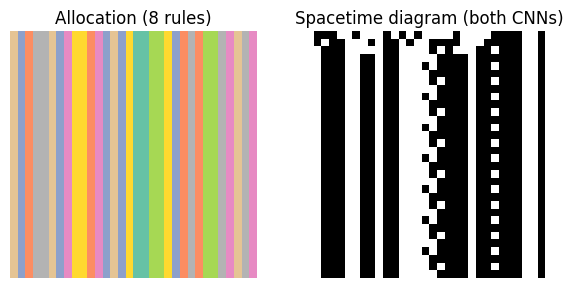

In [8]:
rule_set = [41, 46, 72, 105, 158, 193, 232, 254]
alloc = rng.integers(8, size=32)
nuca = NucaEmulator(32, rule_set, rule_alloc=alloc)
lc, dense = nuca.model(), nuca.model_dense()
print("locally connected:", lc.count_params(), "parameters;  dense:", dense.count_params(), "parameters")
assert lc.count_params() == weights.parameter_count(32, 8, "lc") == 352
assert dense.count_params() == weights.parameter_count(32, 8, "dense") == 8288

x0 = rng.integers(2, size=(4, 32))
expected = reference.evolve(x0, rule_set, 31, alloc)
assert np.array_equal(spacetime(lc, x0, 31), expected)
assert np.array_equal(spacetime(dense, x0, 31), expected)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
axs[0].imshow(np.tile(alloc, (32, 1)), cmap="Set2"); axs[0].set_title("Allocation (8 rules)")
axs[1].imshow(expected[0], cmap="Greys"); axs[1].set_title("Spacetime diagram (both CNNs)")
for ax in axs: ax.axis("off")
plt.show()

Keras offers three implementations of the locally connected layer: mode 1 (the default, used in 2024) loops over
the cells, mode 2 multiplies by a masked dense kernel (and so stores as many weights as the dense variant), and
mode 3 by a sparse one. All three give the same states:

In [9]:
for implementation in (1, 2, 3):
    m = NucaEmulator(32, rule_set, rule_alloc=alloc, implementation=implementation).model()
    assert np.array_equal(spacetime(m, x0, 31), expected)
    print(f"mode {implementation}: {m.count_params():>5} parameters, identical diagram")

mode 1:   352 parameters, identical diagram


mode 2:  8288 parameters, identical diagram


mode 3:   352 parameters, identical diagram


## 4. Bit-identity with CellPyLib and with the published figures

The paper compares the CNNs with [CellPyLib](https://doi.org/10.21105/joss.03608). The inputs of the published
Fig. 1 (rules 30 and 90) were decoded from the paper's PDF (`scripts/extract_published_inputs.py`); the CNN
reproduces the published spacetime diagram cell for cell, as do CellPyLib and the numpy reference:

In [10]:
with np.load("../data/published_inputs/fig1_nuca_rules30_90.npz") as f:
    fig1 = {k: f[k] for k in f.files}
published = fig1["diagram"]
cnn = NucaEmulator(32, fig1["rules"], rule_alloc=fig1["alloc"]).simulate(published[0], 31)
assert np.array_equal(cnn, published)
assert np.array_equal(reference.evolve_cellpylib(published[0], fig1["rules"], 31, fig1["alloc"]), published)
print("Fig. 1: CNN, CellPyLib and the published figure agree on all", published.size, "cells")

Fig. 1: CNN, CellPyLib and the published figure agree on all 1024 cells


The test suite extends this to all 256 rules, many updates, lattices from one cell upwards, both νCA
variants with up to one rule per cell, the other published figures and the outputs of the 2024 code
(`python -m pytest`; see `docs/provenance.md`).

## 5. Aside: the (4, 2, 1) encoding of the paper

The paper describes the first step as a convolution with weights $(4, 2, 1)$, which turns each neighbourhood into
the integer $n = 4s_- + 2s_\circ + s_+$, followed by a one-hot encoding of $n$. The detectors above do both at once:
the index of the active channel *is* $n$. Written literally with standard layers, the one-hot step needs "hat"
functions, $\mathrm{onehot}_i(n) = \mathrm{ReLU}(n-i+1) - 2\,\mathrm{ReLU}(n-i) + \mathrm{ReLU}(n-i-1)$, i.e. a
second hidden layer:

In [11]:
def literal_421_one_hot(x):
    padded = np.concatenate([x[:, -1:], x, x[:, :1]], axis=1).astype(np.float32)[:, :, None]
    n = tf.nn.conv1d(padded, np.array([4, 2, 1], np.float32).reshape(3, 1, 1), 1, "VALID")  # integer 0..7
    i = np.arange(8, dtype=np.float32)
    relu = tf.nn.relu
    return (relu(n - i + 1) - 2 * relu(n - i) + relu(n - i - 1)).numpy()

x = rng.integers(2, size=(8, 32))
eca = EcaEmulator(32, 54).model()
detector_out = tf.keras.Model(eca.input, eca.get_layer("detectors").output)(x[:, :, None].astype(np.float32)).numpy()
assert np.array_equal(literal_421_one_hot(x), detector_out)
print("the literal (4, 2, 1) + one-hot construction equals the eight detectors")

the literal (4, 2, 1) + one-hot construction equals the eight detectors


Both are exact; the detectors need one layer and 32 parameters, which is why the package (and thesis Tab. 7.1)
use them.

## 6. Where to go next

- `figures/` regenerates the five figures of the paper (thesis Figs 7.1–7.5); `python reproduce.py all` runs everything.
- `experiments/training/` studies how to *train* such networks reliably from random weights, for all 256 rules and
  from spacetime diagrams (the published Fig. 3 shows the 2024 recipe).
- `experiments/benchmarks/` measures how fast exact emulation can be once the per-update overhead of
  `model.predict` is removed, against a vectorised numpy baseline.
- Network automata: the analogous construction for Life-like network automata with a graph neural network
  (thesis Sec. 7.2) lives in [`mrollier/network_automata_robustness`](https://github.com/mrollier/network_automata_robustness)
  (`src/automata.py`).